## This notebook can be used to rank a list of nodes from a category that connect to an entity such as a gene. 

In [2]:

import sys
import os
sys.path.append('../TCT/')
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT



### Load Translator resources


In [3]:
APInames, metaKG, Translator_KP_info = translator_metakg.load_translator_resources()

Skipping server without x-maturity: {'url': '/sipr'}


In [4]:
All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

# generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

## Find the neighborhood of an entity from a subset of APIs 


In [5]:
# select a list of APIs to use and a list of predicates to use, if the list is empty, use all APIs and predicates
#selected_APIlist = ['Microbiome KP - TRAPI 1.5.0']
selected_APIlist = []
if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
print(select_APIs)
print(selected_metaKG.shape)


{'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query', 'BioThings Explorer (BTE) TRAPI': 'https://bte.transltr.io/v1/query/', 'Genetics Data Provider for NCATS Biomedical Translator Reasoners': 'https://genetics-kp.transltr.io/genetics_provider/trapi/v1.5/query/', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'Gene-List Network Enrichment Analysis': 'https://translator.broadinstitute.org/gelinea-trapi/v1.5/query/', 'Aragorn(Trapi v1.5.0)': 'https://aragorn.transltr.io/aragorn/query/', 'Answer-coalesce(Trapi v1.5.0)': 'https://answer-coalesce.transltr.io/query/', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'Text Mined Cooccurrence API': 'https://cooccurrence.transltr.io/query/

In [7]:
name_resolver.lookup('Ovarian cancer')


TranslatorNode(curie='MONDO:0008170', label='ovarian cancer', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity'], synonyms=None, curie_synonyms=None, attributes=None, taxa=[])

In order to use the neighborhood finder, we have to look up a CURIE ID for a given term.

In [25]:
#name_resolver.lookup('BCL2')
#name_resolver.lookup('BCL2', return_top_response=False, biolink_type='biolink:Gene',  limit=100, only_taxa='NCBITaxon:9606') # sometimes the identifiers are not in the top 1, users need to check the other returned results


Neighborhood finder identifies all nodes *b* that are connected to the given node *a*, where *b* is part of a defined list of categories - returning the neighborhood of node *a*.

In [18]:
input_node_id, result, result_parsed, result_ranked_by_primary_infores = TCT.Neighborhood_finder('NCBIGene:596',
                                                                                            node2_categories = ['biolink:Gene', 'biolink:Protein'],
                                                                                            APInames = select_APIs,
                                                                                            metaKG = selected_metaKG,
                                                                                            API_predicates = API_predicates)     

MONDO:0008170
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-robokop(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Automat-pharos(Trapi v1.5.0): Success!
Automat-hetionet(Trapi v1.5.0): Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
NodeNorm does not know about these identifiers: NCBIGene:129931243,NCBIGene:109504725,NCBIGene:129996245,NCBIGene:129937389,NCBIGene:107303338,NCBIGene:126861205,NCBIGene:129999452,NCBIGene:130058543,NCBIGene:129390903,NCBIGene:126806658,NCBIGene:126859871,NCBIGene:130059290,NCBIGene:126806659,NCBIGene:130001603,NCBIGene:126860438,NCBIGene:130062899


NodeNorm does not know about these identifiers: NCBIGene:129931243,NCBIGene:129390903,NCBIGene:126806658,NCBIGene:126859871,NCBIGene:130059290,NCBIGene:126806659,NCBIGene:130001603,NCBIGene:109504725,NCBIGene:126860438,NCBIGene:130058543,NCBIGene:129996245,NCBIGene:129937389,NCBIGene:107303338,NCBIGene:126861205,NCBIGene:129999452,NCBIGene:130062899
[Text(0.5, 0, 'ERBB2'), Text(2.5, 0, 'BRCA1'), Text(4.5, 0, 'CTNNB1'), Text(6.5, 0, 'BRCA2'), Text(8.5, 0, 'OPCML'), Text(10.5, 0, 'MSH2'), Text(12.5, 0, 'KRAS'), Text(14.5, 0, 'EGFR'), Text(16.5, 0, 'MYC'), Text(18.5, 0, 'RAD51D'), Text(20.5, 0, 'MLH1'), Text(22.5, 0, 'MET'), Text(24.5, 0, 'BARD1'), Text(26.5, 0, 'ATM'), Text(28.5, 0, 'PARP1'), Text(30.5, 0, 'TUBB3'), Text(32.5, 0, 'RRAS2'), Text(34.5, 0, 'MSLN'), Text(36.5, 0, 'CDKN1B'), Text(38.5, 0, 'NR5A1'), Text(40.5, 0, 'MRE11'), Text(42.5, 0, 'FOLR1'), Text(44.5, 0, 'NBN'), Text(46.5, 0, 'DYRK1B'), Text(48.5, 0, 'CHMP4C')]


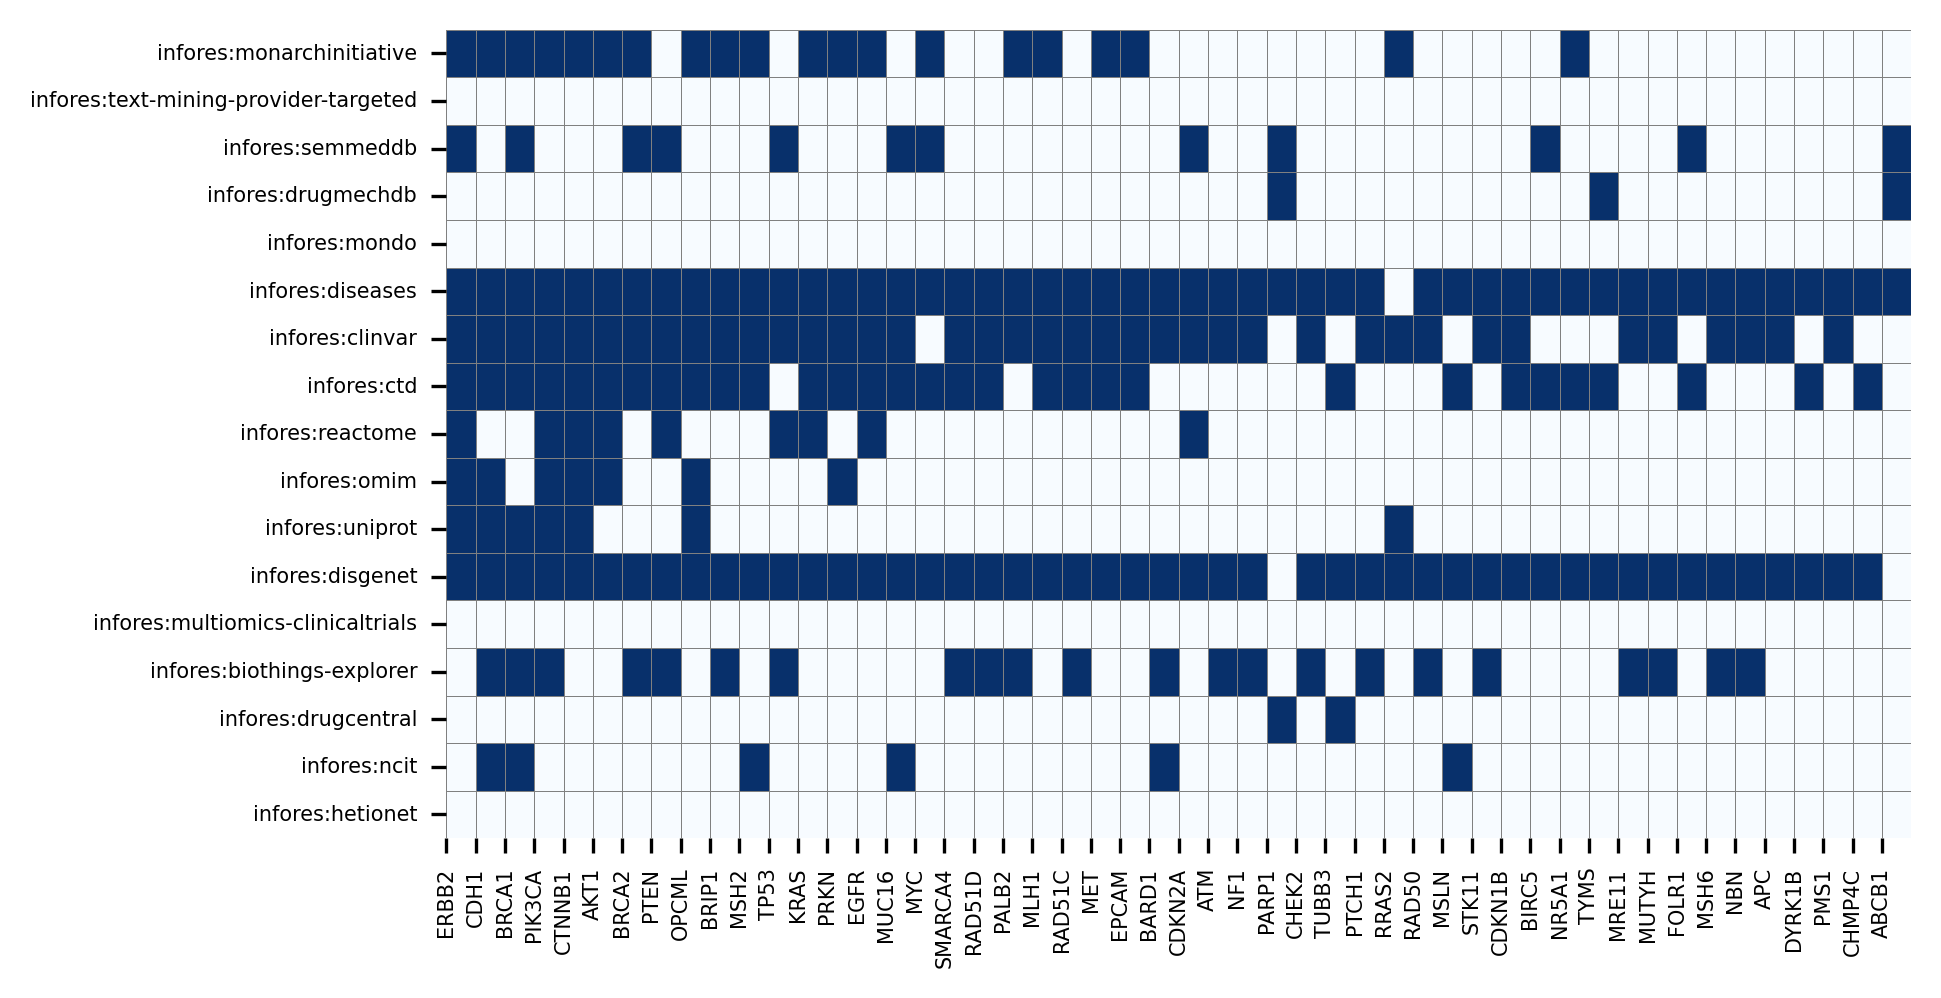

[Text(0.5, 0, 'ERBB2'), Text(2.5, 0, 'BRCA1'), Text(4.5, 0, 'CTNNB1'), Text(6.5, 0, 'BRCA2'), Text(8.5, 0, 'OPCML'), Text(10.5, 0, 'MSH2'), Text(12.5, 0, 'KRAS'), Text(14.5, 0, 'EGFR'), Text(16.5, 0, 'MYC'), Text(18.5, 0, 'RAD51D'), Text(20.5, 0, 'MLH1'), Text(22.5, 0, 'MET'), Text(24.5, 0, 'BARD1'), Text(26.5, 0, 'ATM'), Text(28.5, 0, 'PARP1'), Text(30.5, 0, 'TUBB3'), Text(32.5, 0, 'RRAS2'), Text(34.5, 0, 'MSLN'), Text(36.5, 0, 'CDKN1B'), Text(38.5, 0, 'NR5A1'), Text(40.5, 0, 'MRE11'), Text(42.5, 0, 'FOLR1'), Text(44.5, 0, 'NBN'), Text(46.5, 0, 'DYRK1B'), Text(48.5, 0, 'CHMP4C')]


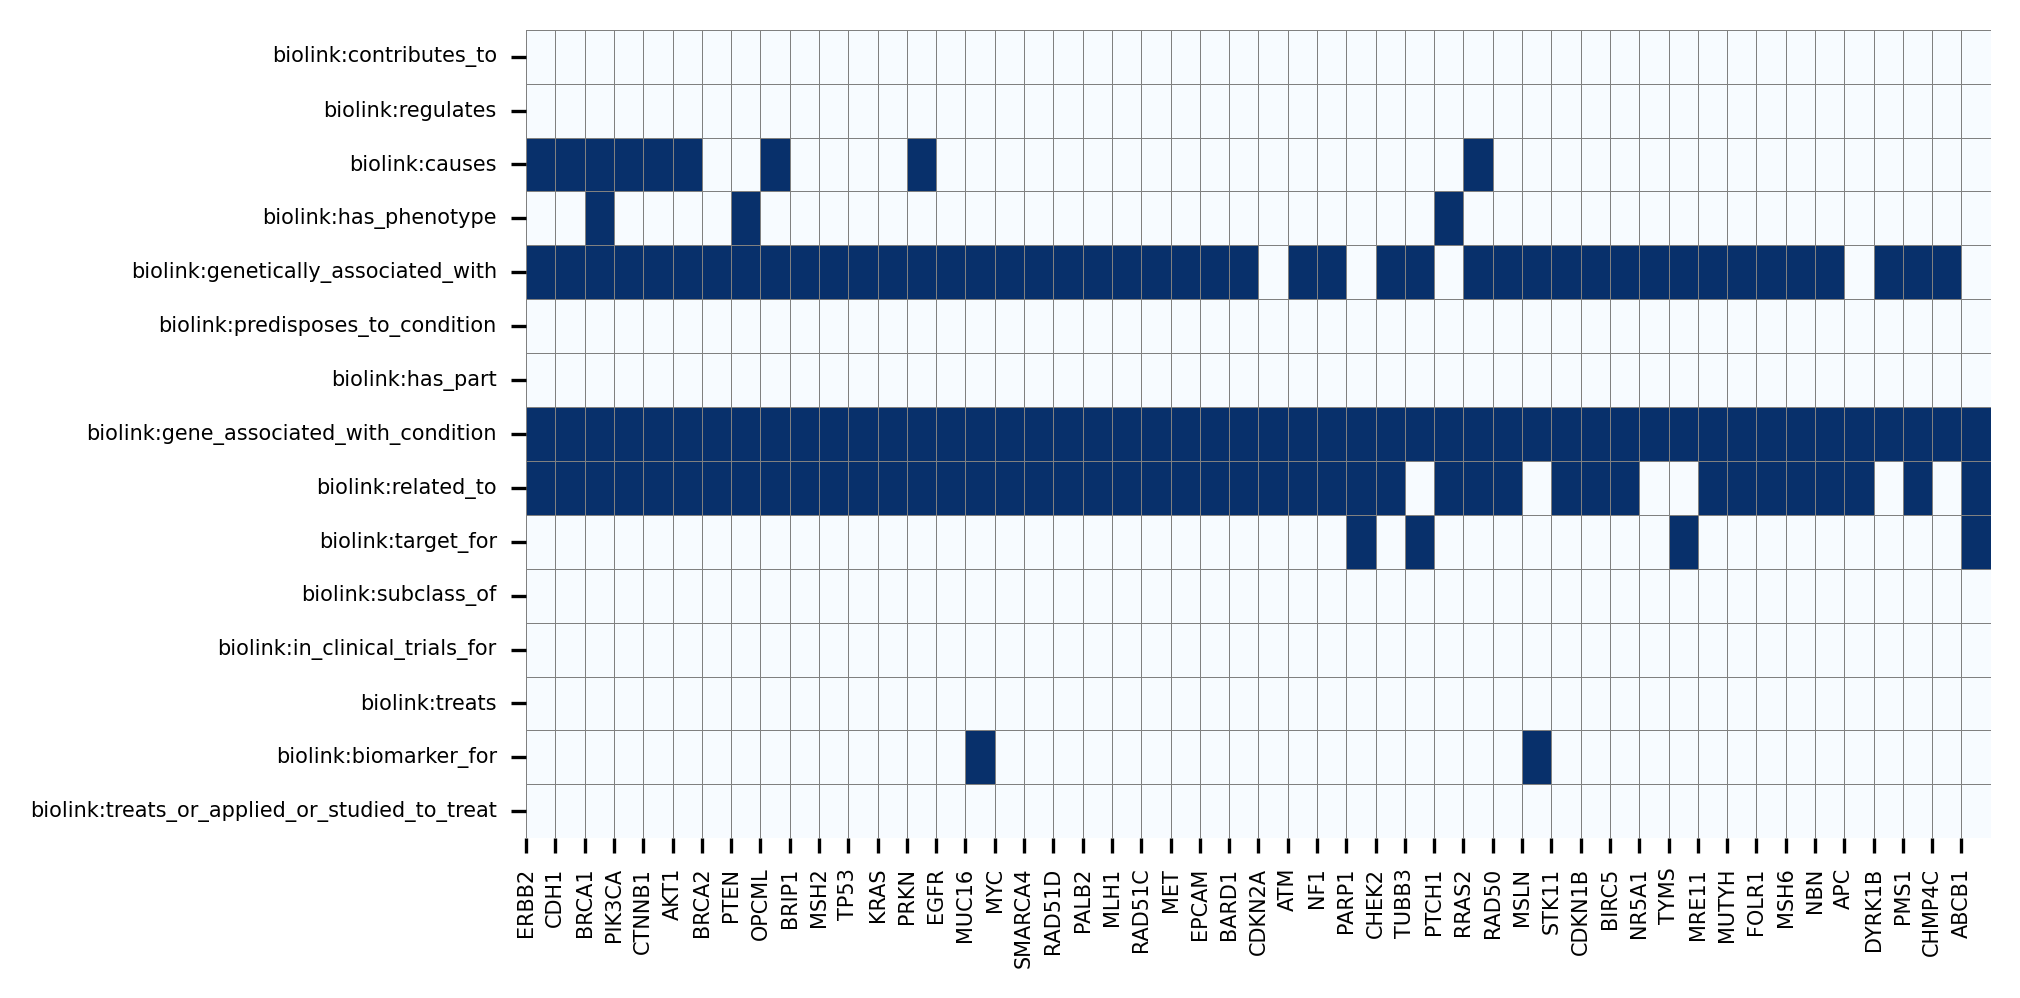

,ERBB2,CDH1,BRCA1,PIK3CA,CTNNB1,AKT1,BRCA2,PTEN,OPCML,BRIP1,...,ATG3,HOXA10,MSI2,GDPD1,THY1,UCHL1,WNT3A,TMPRSS15,APP,NCBIGene:130062899
biolink:contributes_to,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:regulates,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:causes,1,1,1,1,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
biolink:has_phenotype,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:genetically_associated_with,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:predisposes_to_condition,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:has_part,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:gene_associated_with_condition,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
biolink:related_to,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1
biolink:target_for,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores, result_parsed, 
                                num_of_nodes = 50, input_query = input_node_id, 
                                fontsize = 5)

In [23]:
result_ranked_by_primary_infores

,output_node,Name,Num_of_primary_infores,type_of_nodes,unique_predicates
46,NCBIGene:2064,ERBB2,9,subject,"[biolink:causes, biolink:genetically_associate..."
274,NCBIGene:999,CDH1,9,subject,"[biolink:causes, biolink:genetically_associate..."
203,NCBIGene:672,BRCA1,9,subject,"[biolink:genetically_associated_with, biolink:..."
147,NCBIGene:5290,PIK3CA,9,subject,"[biolink:causes, biolink:genetically_associate..."
33,NCBIGene:1499,CTNNB1,8,subject,"[biolink:causes, biolink:genetically_associate..."
...,...,...,...,...,...
1199,NCBIGene:7345,UCHL1,1,subject,[biolink:gene_associated_with_condition]
1200,NCBIGene:89780,WNT3A,1,subject,[biolink:gene_associated_with_condition]
1201,NCBIGene:5651,TMPRSS15,1,subject,[biolink:gene_associated_with_condition]
1202,NCBIGene:351,APP,1,subject,[biolink:gene_associated_with_condition]


In [24]:
from TCT import TCT_Visualization

dic_graph = TCT_Visualization.visualize_neighborhood_graph(result, show_label=True, height="500", width="100%")

NodeNorm does not know about these identifiers: NCBIGene:107303338,orphanet:209285,orphanet:225351,NCBIGene:130001603,NCBIGene:130062899,orphanet:395930,NCBIGene:126859871,NCBIGene:109504725,NCBIGene:130058543,NCBIGene:129931243,NCBIGene:126861205,NCBIGene:129996245,orphanet:121904,NCBIGene:129390903,NCBIGene:129999452,NCBIGene:126860438,NCBIGene:126806659,NCBIGene:126806658,NCBIGene:129937389,NCBIGene:130059290
associated_with.html


In [ ]:
# End of the example
